# Bell Pair on Real IBM Quantum Hardware

This notebook creates a simple Bell pair (maximally entangled state) and runs it on real IBM quantum hardware.

In [1]:
import json
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

## Configuration

In [2]:
# Load IBM Quantum credentials
SECRETS_PATH = '../secrets/keys.json'
NUM_SHOTS = 4096

with open(SECRETS_PATH) as f:
    keys = json.load(f)

# Connect to IBM Quantum
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    token=keys["qiskit-api-key"]
)

# Get backend - using ibm_fez or least busy available backend
try:
    backend = service.backend('ibm_fez')
except:
    backend = service.least_busy(operational=True, simulator=False)

print(f"Backend: {backend.name}")
print(f"Qubits: {backend.num_qubits}")
print(f"Status: {backend.status().status_msg}")
print(f"Pending jobs: {backend.status().pending_jobs}")

qiskit_runtime_service._discover_account:WARNING:2026-01-27 13:38:44,711: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-01-27 13:38:47,006: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-27 13:38:47,007: Using instance: open-instance, plan: open


Backend: ibm_fez
Qubits: 156
Status: active
Pending jobs: 8


## Create Bell Pair Circuit

A Bell pair is created by:
1. Applying a Hadamard gate to put the first qubit in superposition: $|0\rangle \rightarrow \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$
2. Applying a CNOT gate to entangle the two qubits: $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$

This creates the Bell state $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$

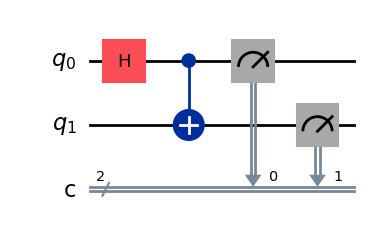

In [3]:
# Create Bell pair circuit
qc = QuantumCircuit(2, 2)

# Create Bell state |Phi+> = (|00> + |11>) / sqrt(2)
qc.h(0)       # Hadamard on qubit 0
qc.cx(0, 1)   # CNOT with control=0, target=1

# Measure both qubits
qc.measure([0, 1], [0, 1])

# Draw the circuit
qc.draw('mpl')

## Transpile for Hardware

Original circuit depth: 3
Transpiled circuit depth: 8
Transpiled gate counts: OrderedDict({'rz': 6, 'sx': 3, 'measure': 2, 'cz': 1})


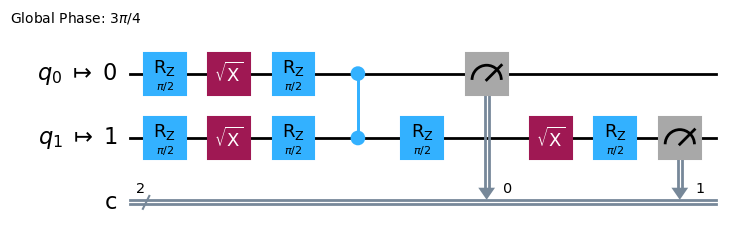

In [4]:
# Transpile for the real backend
transpiled_qc = transpile(qc, backend=backend, optimization_level=1)

print(f"Original circuit depth: {qc.depth()}")
print(f"Transpiled circuit depth: {transpiled_qc.depth()}")
print(f"Transpiled gate counts: {transpiled_qc.count_ops()}")

# Show transpiled circuit
transpiled_qc.draw('mpl', idle_wires=False)

## Run on Real Hardware

In [5]:
# Create sampler and run
sampler = SamplerV2(backend)

print(f"Submitting job to {backend.name}...")
job = sampler.run([transpiled_qc], shots=NUM_SHOTS)
print(f"Job ID: {job.job_id()}")
print("Waiting for results (this may take a while if there's a queue)...")

Submitting job to ibm_fez...
Job ID: d5sgceccqoec73diibog
Waiting for results (this may take a while if there's a queue)...


In [6]:
# Get results
result = job.result()


In [7]:

# Extract counts from the result
print(result[0].data.c.get_counts())

{'00': 2005, '11': 1858, '10': 140, '01': 93}


In [8]:
data_bin = result[0].data
# Find the classical register with counts
counts = None
for attr_name in dir(data_bin):
    if not attr_name.startswith('_'):
        attr = getattr(data_bin, attr_name)
        if hasattr(attr, 'get_counts'):
            counts = attr.get_counts()
            break

print(f"\nResults ({NUM_SHOTS} shots):")
print(f"Counts: {counts}")

# Calculate probabilities
total = sum(counts.values())
print(f"\nProbabilities:")
for outcome, count in sorted(counts.items()):
    prob = count / total
    print(f"  |{outcome}>: {prob:.4f} ({count} counts)")


Results (4096 shots):
Counts: {'00': 2005, '11': 1858, '10': 140, '01': 93}

Probabilities:
  |00>: 0.4895 (2005 counts)
  |01>: 0.0227 (93 counts)
  |10>: 0.0342 (140 counts)
  |11>: 0.4536 (1858 counts)


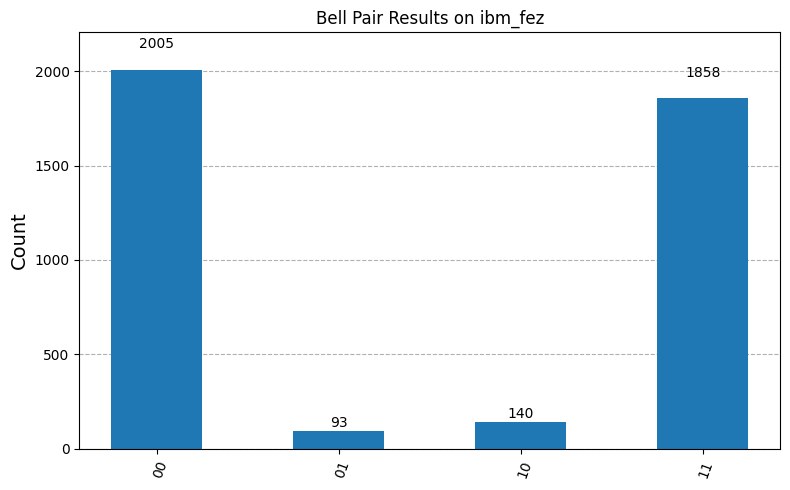


Bell State Quality Metrics
Correct outcomes (|00> + |11>): 3863 (94.31%)
Error outcomes (|01> + |10>):   233 (5.69%)

Estimated Bell state fidelity: 0.9431


In [9]:
# Visualize results
fig, ax = plt.subplots(figsize=(8, 5))
plot_histogram(counts, ax=ax, title=f"Bell Pair Results on {backend.name}")
plt.tight_layout()
plt.show()

# Calculate fidelity metrics
ideal_outcomes = ['00', '11']  # Bell state should only have |00> and |11>
error_outcomes = ['01', '10']  # These indicate errors

correct_counts = sum(counts.get(o, 0) for o in ideal_outcomes)
error_counts = sum(counts.get(o, 0) for o in error_outcomes)

fidelity = correct_counts / total
error_rate = error_counts / total

print(f"\n{'='*50}")
print(f"Bell State Quality Metrics")
print(f"{'='*50}")
print(f"Correct outcomes (|00> + |11>): {correct_counts} ({fidelity:.2%})")
print(f"Error outcomes (|01> + |10>):   {error_counts} ({error_rate:.2%})")
print(f"\nEstimated Bell state fidelity: {fidelity:.4f}")

## Analysis

For an ideal Bell state $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$:
- We expect 50% probability for |00⟩
- We expect 50% probability for |11⟩
- We expect 0% probability for |01⟩ and |10⟩

Any deviation from this indicates noise/errors in the quantum hardware.